# Digital Experimentation and Causal Analysis- Group Project, Group 50- TXB 
Lucia Musizzano, Pietro Franchi, Leonardo Cantú, 71993 Maria Teresa Neves Silva, José João Nascimento Almeida
## A/B Test – Visual Redesign of Benefit Plans
Group 50 – Digital Experimentation and Causal Analysis
This notebook implements the analysis pipeline for our A/B test.
It includes:
- Data loading  
- Metric computation  
- Statistical tests  
- Power analysis  
- Interpretation  
## 1. Environment Setup

The first step consists of importing all required libraries for the analysis.

These libraries will be used for:

- data manipulation and processing
- statistical testing
- power analysis
- visualization

The analysis will be conducted using Python with `pandas`, `numpy`, `scipy`, `statsmodels`, and `matplotlib`.

In [1]:
# 1. Import Libraries & Configure plotting style:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from io import StringIO
from scipy.stats import ttest_ind, norm
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize, proportions_ztest
plt.style.use('seaborn-v0_8')

# 2. Load and repair dataset
data_path = "TXB_50_landingpage(in).csv"

with open(data_path, "r", encoding="utf-8") as f:
    lines = f.readlines()

fixed_lines = []
for line in lines:
    line = line.strip()
    if line.startswith('"') and line.endswith('"'):
        line = line[1:-1]
    line = line.replace('""', '"')
    fixed_lines.append(line)

fixed_csv = "\n".join(fixed_lines)
df = pd.read_csv(StringIO(fixed_csv))

# 3. Cleaning, first check
df.head()


,group_id,arm,visitor_id,arrival_time,exit_time,time_on_page_sec,exit_rate,ctr_opportunities,ctr_newsletter,ctr_donation,ctr_events,kpi_x,kpi_y,scroll_depth_pct,ctr_partner_banner,page_load_time_ms
0,TXB_50,pre,1,2026-02-22 23:56:19.912141,2026-02-23 00:10:37.358044,857.4,0,0,0,0,0,20.99,0,15.8,0,1124.6
1,TXB_50,pre,2,2026-02-23 00:04:21.780854,2026-02-23 00:07:08.45178,166.7,0,0,0,0,0,60.47,0,21.1,0,1081.1
2,TXB_50,pre,3,2026-02-23 00:19:06.142652,2026-02-23 00:19:36.641006,30.5,0,0,0,0,0,17.21,1,34.5,0,1068.1
3,TXB_50,pre,4,2026-02-23 00:50:03.467378,2026-02-23 00:50:12.139395,8.7,1,0,0,0,0,0.95,0,7.3,0,2424.9
4,TXB_50,pre,5,2026-02-23 01:08:11.793118,2026-02-23 01:15:44.427531,452.6,0,0,0,0,0,46.47,0,35.2,0,1445.2


After loading the dataset, a first inspection is performed to verify that the data has been correctly parsed.

Displaying the first rows of the dataset allows us to confirm that:
- all columns are present
- values are correctly aligned
- the dataset structure matches expectations

In [2]:
# 4. Data Structure Overview
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1234 entries, 0 to 1233
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   group_id            1234 non-null   object 
 1   arm                 1234 non-null   object 
 2   visitor_id          1234 non-null   int64  
 3   arrival_time        1234 non-null   object 
 4   exit_time           1234 non-null   object 
 5   time_on_page_sec    1234 non-null   float64
 6   exit_rate           1234 non-null   int64  
 7   ctr_opportunities   1234 non-null   int64  
 8   ctr_newsletter      1234 non-null   int64  
 9   ctr_donation        1234 non-null   int64  
 10  ctr_events          1234 non-null   int64  
 11  kpi_x               1234 non-null   float64
 12  kpi_y               1234 non-null   int64  
 13  scroll_depth_pct    1234 non-null   float64
 14  ctr_partner_banner  1234 non-null   int64  
 15  page_load_time_ms   1234 non-null   float64
dtypes: flo

In [3]:
# 5. Dataset Variables: The list of dataset columns is inspected to verify that all relevant metrics are available for the analysis
df.columns.tolist()

['group_id',
 'arm',
 'visitor_id',
 'arrival_time',
 'exit_time',
 'time_on_page_sec',
 'exit_rate',
 'ctr_opportunities',
 'ctr_newsletter',
 'ctr_donation',
 'ctr_events',
 'kpi_x',
 'kpi_y',
 'scroll_depth_pct',
 'ctr_partner_banner',
 'page_load_time_ms']

In [4]:
# 6. Experimental Groups and KPIs: The unique values in the "arm" and "kpi_y" columns are checked to confirm the presence of expected experimental groups and key performance indicators.
df["arm"].unique(), df["kpi_y"].unique()

(array(['pre', 'control', 'treatment'], dtype=object), array([0, 1]))

In [5]:
# 7. Distribution of Observations Across Groups: The number and proportion of observations in each experimental arm are examined.
df["arm"].value_counts(normalize=True)

arm
control      0.363047
treatment    0.363047
pre          0.273906
Name: proportion, dtype: float64

## 2. Computation of A/B Test Metrics

To evaluate the effect of the redesigned landing page, we compute a set of key performance indicators (KPIs) for each experimental group.

The KPIs reflect the goals defined in the experiment proposal.

Primary and supporting metrics are mapped to the available variables in the dataset as follows:

- **Plan CTR (Primary KPI)** → **kpi_y**: Binary outcome representing whether the user performed the key click action.

- **Simulation Interaction Rate (Secondary KPI)** → **Kpi_x**: Continuous metric representing deeper engagement with the page.

- **Exploration / Engagement Metric** → **scroll_depth_pct**: Measures how much of the page users explore. Higher scroll depth suggests clearer hierarchy and stronger engagement.

- **Bounce Rate (Guardrail KPI)** → **exit_rate**: Measures whether users leave the page without further interaction.

Metrics are computed separately for the **control** and **treatment** groups to compare the original and redesigned landing page versions.

In [6]:
# 6. Creating metrics dictionary: We store all computed KPIs in a dictionary for easier comparison.
metrics = {}

# 7. Primary KPI: Plan CTR: kpi_y is the binary success metric (click / conversion)

metrics['PlanCTR_control'] = df[df.arm == "control"].kpi_y.mean()
metrics['PlanCTR_treatment'] = df[df.arm == "treatment"].kpi_y.mean()


# 8. Secondary KPI: Simulation interaction proxy: kpi_x captures deeper engagement with the page

metrics['SimulationRate_control'] = df[df.arm == "control"].kpi_x.mean()
metrics['SimulationRate_treatment'] = df[df.arm == "treatment"].kpi_x.mean()


# 9. Engagement metric: Scroll depth: Higher scroll depth indicates stronger exploration of the page content

metrics['ScrollDepth_control'] = df[df.arm == "control"].scroll_depth_pct.mean()
metrics['ScrollDepth_treatment'] = df[df.arm == "treatment"].scroll_depth_pct.mean()


# 10. Guardrail metric: Exit rate:Ensures the redesign does not increase bounce / early exits

metrics['ExitRate_control'] = df[df.arm == "control"].exit_rate.mean()
metrics['ExitRate_treatment'] = df[df.arm == "treatment"].exit_rate.mean()


# 11. Display results
metrics_df = pd.DataFrame(metrics, index=['Value'])
metrics_df.T                                       # Transpose metrics table for readability

,Value
PlanCTR_control,0.100446
PlanCTR_treatment,0.091518
SimulationRate_control,29.637902
SimulationRate_treatment,32.213170
ScrollDepth_control,37.556473
ScrollDepth_treatment,37.629687
ExitRate_control,0.220982
ExitRate_treatment,0.178571


### Descriptive Comparison of KPIs

The table above reports the average value of each KPI for the control and treatment groups. At a descriptive level, several patterns can be observed:

- **Plan CTR** appears slightly lower in the treatment group compared to the control group.  
- **Simulation Interaction Rate** is higher in the treatment group, suggesting stronger progression toward deeper interaction with the page.
- **Scroll Depth** is very similar across the two groups, indicating that overall page exploration remains stable.
- **Exit Rate** is lower in the treatment group, suggesting that fewer users leave the page early.

These differences provide an initial descriptive comparison between the two versions of the landing page.

However, descriptive differences alone are not sufficient to determine whether the redesign had a meaningful effect.  
To assess whether the observed differences are statistically significant, formal hypothesis tests are required.


## 3. Statistical Tests

To evaluate whether the observed differences between the control and treatment groups are statistically significant, we perform hypothesis tests for each KPI.

The tests used depend on the type of variable:

- **Proportion Z-test** for the primary binary KPI (**kpi_y**)
- **Welch two-sample t-tests** for continuous metrics (**kpi_x**, **scroll_depth_pct**, **exit_rate**)

The null hypothesis assumes that the control and treatment groups have equal mean outcomes.

Rejecting the null hypothesis indicates that the redesign had a statistically significant effect on the corresponding metric.

In [7]:
# 12. Statistical tests for A/B experiment

# Separate datasets
control = df[df.arm == "control"]
treatment = df[df.arm == "treatment"]


# 13. Proportion test for primary KPI (Plan CTR)

successes = [
    treatment.kpi_y.sum(),
    control.kpi_y.sum()
]

observations = [
    len(treatment),
    len(control)
]

z_stat, p_ctr = proportions_ztest(successes, observations)

print("----- Proportion test: Plan CTR -----")
print("z-stat:", z_stat)
print("p-value:", p_ctr)


# 14. T-test for secondary KPI (Simulation interaction proxy)

t_kpix, p_kpix = ttest_ind(
    treatment.kpi_x,
    control.kpi_x,
    equal_var=False
)

print("\n----- T-test: Simulation Interaction (kpi_x) -----")
print("p-value:", p_kpix)


# 15. T-test for engagement metric (Scroll depth)

t_scroll, p_scroll = ttest_ind(
    treatment.scroll_depth_pct,
    control.scroll_depth_pct,
    equal_var=False
)

print("\n----- T-test: Scroll Depth -----")
print("p-value:", p_scroll)


# 16. T-test for guardrail metric (Exit rate)

t_exit, p_exit = ttest_ind(
    treatment.exit_rate,
    control.exit_rate,
    equal_var=False
)

print("\n----- T-test: Exit Rate -----")
print("p-value:", p_exit)

----- Proportion test: Plan CTR -----
z-stat: -0.453651405869816
p-value: 0.6500797477705477

----- T-test: Simulation Interaction (kpi_x) -----
p-value: 0.1444053104601129

----- T-test: Scroll Depth -----
p-value: 0.9727975606148219

----- T-test: Exit Rate -----
p-value: 0.11264431457028377


In [8]:
# 17. Conclusion: We check if the primary KPI (Plan CTR) shows a statistically significant difference between treatment and control groups at a significance level of 0.05.

alpha = 0.05

print("Significant:", p_ctr < alpha)

Significant: False


### Interpretation of Statistical Tests

The hypothesis tests evaluate whether the observed differences between the control and treatment groups are statistically significant.

A significance threshold of **α = 0.05** is used. If the p-value is lower than this threshold, the null hypothesis of equal outcomes between the two groups is rejected.

### Results interpretation

**Plan CTR (primary KPI)**  
The proportion test returned a p-value of **0.65**, which is well above the significance threshold. This indicates that the difference in the click-through rate between the redesigned page (treatment) and the original version (control) is **not statistically significant**.

**Simulation Interaction (kpi_x)**  
The t-test for the engagement proxy returned a p-value of **0.144**. Although the treatment group shows slightly higher engagement, the difference is **not statistically significant**.

**Scroll Depth**  
The p-value of **0.97** indicates that the scroll behavior between the two groups is essentially identical. The redesign does not appear to affect how deeply users explore the page.

**Exit Rate (Guardrail metric)**  
The exit rate comparison yields a p-value of **0.113**, which means that the redesign does **not significantly increase early exits**. This suggests that the redesign does not harm the user experience.

### Overall conclusion

None of the tested metrics show statistically significant differences between the control and treatment groups. This suggests that the proposed redesign does **not produce measurable behavioral improvements in the current dataset**. Additional data or a longer experiment duration may be required to detect meaningful effects.

## 4. Power Analysis

Power analysis evaluates whether the experiment has enough observations to detect a meaningful effect.

Statistical power represents the probability of correctly rejecting the null hypothesis when a real effect exists.

In A/B testing, a power of **0.8 (80%)** is typically considered sufficient.

Using the observed difference in the primary KPI (Plan CTR), we estimate the statistical power of the experiment given the current sample size.

In [9]:
# 18. Power analysis for the primary KPI (Plan CTR)

from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize


    # 18.1. Observed CTRs from the dataset
p_control = control.kpi_y.mean()
p_treatment = treatment.kpi_y.mean()

    # 18.2. Sample sizes
n_control = len(control)
n_treatment = len(treatment)

    # 18.3. Effect size (Cohen's h)
effect = proportion_effectsize(p_treatment, p_control)

    # 19.4. Power calculation
analysis = NormalIndPower()

power = analysis.solve_power(
    effect_size=effect,
    nobs1=n_control,
    alpha=0.05,
    ratio=n_treatment / n_control
)

print("----- Power Analysis -----")
print("Sample size control:", n_control)
print("Sample size treatment:", n_treatment)
print("Effect size (Cohen's h):", effect)
print("Observed power:", power)

----- Power Analysis -----
Sample size control: 448
Sample size treatment: 448
Effect size (Cohen's h): -0.03031857565326035
Observed power: 0.07390335286787215


### Power Analysis Interpretation

The power analysis evaluates whether the experiment has enough observations to detect the observed difference in the primary KPI.

The estimated power is **0.074**, which is far below the conventional threshold of **0.80**.

This indicates that the experiment is **underpowered** for detecting an effect of the size observed in the data. In other words, even if a small true effect exists, the current sample size is unlikely to detect it reliably.

The estimated effect size is also very small (**Cohen’s h ≈ -0.03**), suggesting that the difference in Plan CTR between treatment and control is minimal.

Therefore, the lack of statistically significant results should be interpreted with caution:

- it may indicate that the redesign truly has little or no effect
- but it may also reflect insufficient statistical power to detect a small effect

Overall, the current evidence does not support a meaningful improvement in the primary KPI, and a larger sample or a stronger treatment effect would be needed to draw firmer conclusions.

## 5. Visualization of KPI Differences

To visually compare the control and treatment groups, we generate bar charts for the main metrics used in the experiment.

These charts provide an intuitive representation of the differences between the two versions of the landing page.

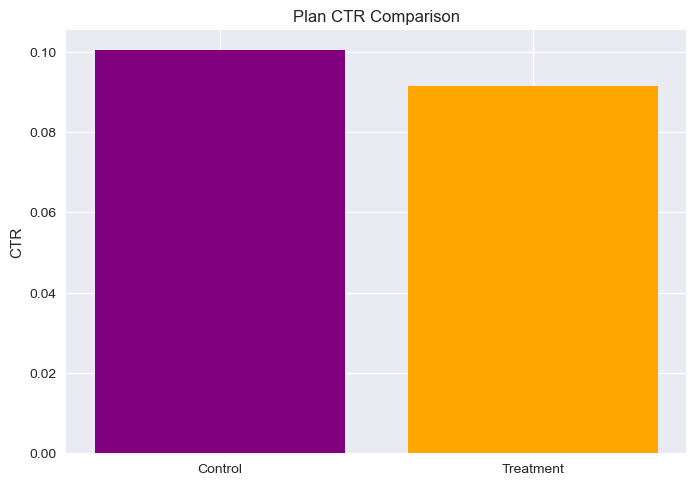

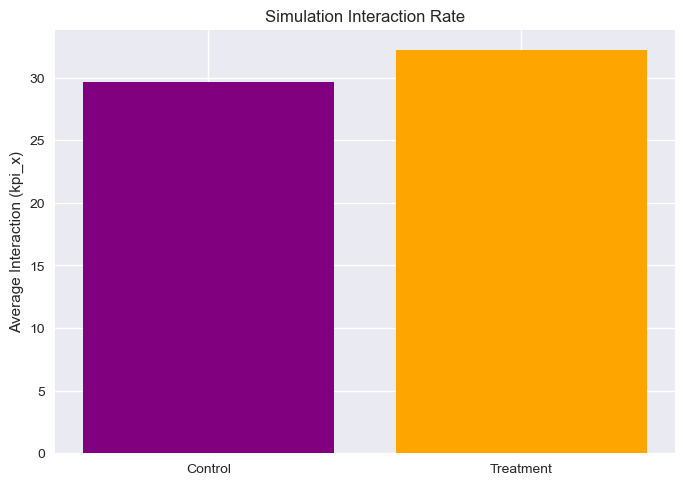

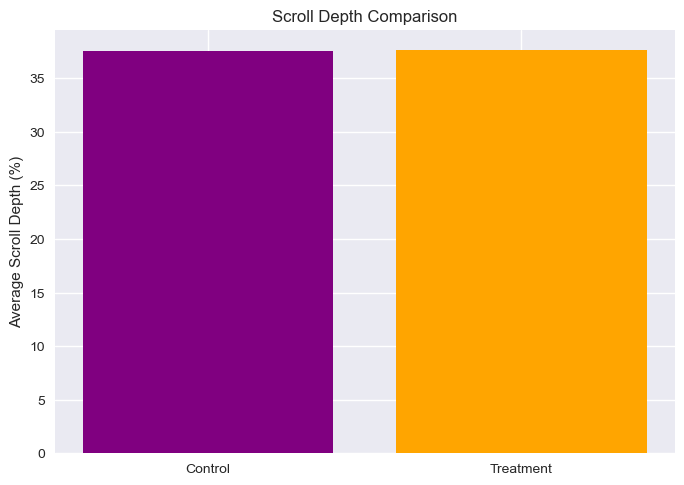

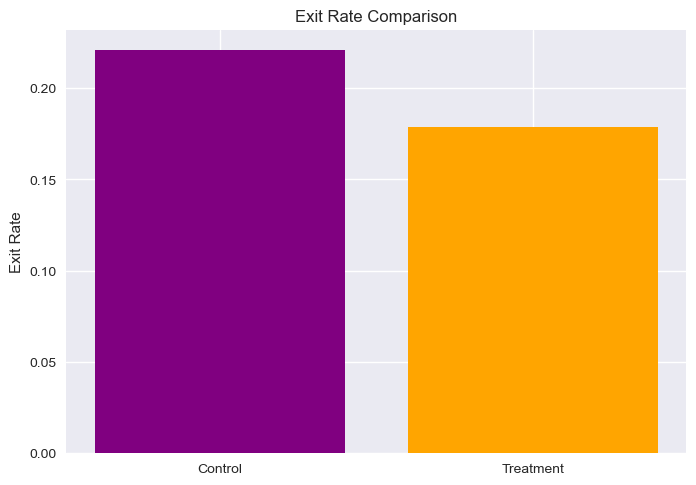

In [10]:
# 19. Plan CTR comparison chart

plt.bar(
    ["Control", "Treatment"],
    [metrics["PlanCTR_control"], metrics["PlanCTR_treatment"]],
    color=["purple", "orange"]
)

plt.title("Plan CTR Comparison")
plt.ylabel("CTR")
plt.show()


# 20. Simulation Interaction Rate comparison

plt.bar(
    ["Control", "Treatment"],
    [metrics["SimulationRate_control"], metrics["SimulationRate_treatment"]],
    color=["purple", "orange"]
)

plt.title("Simulation Interaction Rate")
plt.ylabel("Average Interaction (kpi_x)")
plt.show()


# 21. Scroll Depth comparison

plt.bar(
    ["Control", "Treatment"],
    [metrics["ScrollDepth_control"], metrics["ScrollDepth_treatment"]],
    color=["purple", "orange"]
)

plt.title("Scroll Depth Comparison")
plt.ylabel("Average Scroll Depth (%)")
plt.show()


# 22. Exit Rate comparison

plt.bar(
    ["Control", "Treatment"],
    [metrics["ExitRate_control"], metrics["ExitRate_treatment"]],
    color=["purple", "orange"]
)

plt.title("Exit Rate Comparison")
plt.ylabel("Exit Rate")
plt.show()

### Visualization Interpretation

The bar charts show the descriptive differences between the control and treatment groups.

The treatment version exhibits:
- slightly lower Plan CTR
- higher interaction proxy (kpi_x)
- nearly identical scroll depth
- slightly lower exit rate

While these visual differences may suggest small behavioral changes, the statistical tests indicate that none of these differences are statistically significant.

Therefore, the observed variations should be interpreted as random fluctuations rather than evidence of a meaningful impact of the redesign.

## 6. Final Conclusion

This notebook evaluated the impact of the redesigned Benefit Plans landing page by comparing the **control** and **treatment** groups on the KPIs mapped from the original proposal.

### Summary of descriptive results

At a descriptive level, the treatment version showed:

- a slightly **lower Plan CTR**
- a **higher simulation interaction proxy** (**kpi_x**)
- an almost unchanged **scroll depth**
- a slightly **lower exit rate**

These patterns suggest that the redesign may have improved some aspects of engagement, while not clearly improving the main click-based conversion outcome.

### Summary of statistical results

The formal hypothesis tests showed that none of the observed differences were statistically significant at the 5% level:

- **Plan CTR**: not statistically significant
- **Simulation Interaction proxy (`pi_x)**: not statistically significant
- **Scroll Depth**: not statistically significant
- **Exit Rate**: not statistically significant

This means that, based on the current dataset, the redesign does not provide statistically reliable evidence of improved user behavior.

### Power analysis

The power analysis for the primary KPI returned a statistical power of approximately **0.074**, which is far below the commonly recommended threshold of **0.80**.

This indicates that the experiment is **underpowered** for detecting an effect of the observed size. Therefore, the lack of significance should be interpreted cautiously: the redesign may truly have little effect, but the sample may also be too small to detect a small real effect.

### Final assessment

Overall, the current results do **not support rolling out the redesigned version based on the available evidence**.

Although the treatment version does not appear to harm the user experience, it also does not generate a statistically significant improvement in the primary KPI. A stronger redesign, a larger sample, or a longer testing period would be needed to assess the effect more reliably.